## **Анализ данных (EDA)**


In [1]:
#Импортирование библиотек
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Считываем даные
df = pd.read_excel('Данные_для_курсовои_Классическое_МО.xlsx')

df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


### Общая информация о данных

In [3]:
#Размер датасета
df.shape

(1001, 214)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [5]:
df.describe()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,500.000000,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,289.108111,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,250.000000,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,500.000000,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,750.000000,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,1000.000000,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


Данные с датасета содержат 210 признаков и 3 целевые переменные - 'IC50, mM', 'CC50, mM', 'SI'.Количество наблюдений - 1001. Все признаки в данных представлены числовыми значениями. По описательной статистике видно, что в данных могут присутствовать выбросы. Диапазон значений в признаках различается, поэтому необходимо будет масштабировать данные перед обучением.

### Проверка пропусков и дубликатов

In [6]:
# Проверка пропусков
(df.isna().mean()*100).sort_values(ascending=False)

MaxAbsPartialCharge    0.2997
MinAbsPartialCharge    0.2997
MaxPartialCharge       0.2997
MinPartialCharge       0.2997
BCUT2D_MWLOW           0.2997
                        ...  
fr_thiazole            0.0000
fr_thiocyan            0.0000
fr_thiophene           0.0000
fr_unbrch_alkane       0.0000
fr_urea                0.0000
Length: 214, dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

В данных есть небольшое количество (менее 0.3% для признаков). Дубликаты отсутствуют.

### Первичная предобработка данных

In [183]:
#Удаляем столбец с индексами
df = df.drop(columns=['Unnamed: 0'])

In [8]:
#Заполним пропуски медианой, т.к. доля пропусков мала
df = df.fillna(df.median(numeric_only=True))
df.isna().sum().sum()

np.int64(0)

### Анализ целевых переменных

In [9]:
#Проверка пропусков
(df[['IC50, mM', 'CC50, mM', 'SI']].isna().mean()*100).sort_values(ascending=False)

IC50, mM    0.0
CC50, mM    0.0
SI          0.0
dtype: float64

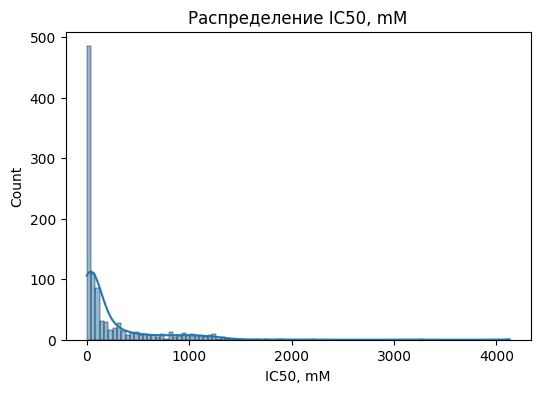

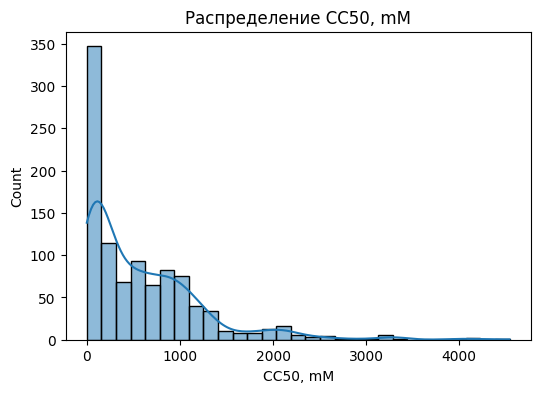

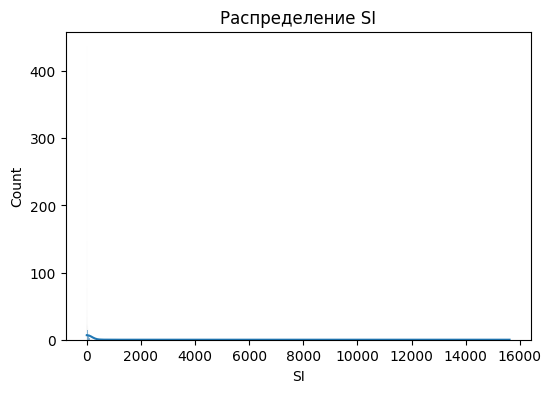

In [10]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

for col in targets:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')
    plt.show()

Графики распределения IC50, CC50 имеют правостороннюю асимметрию, что свидетельствует о наличии выбросов.


Проверим корреляцию между целевыми переменными

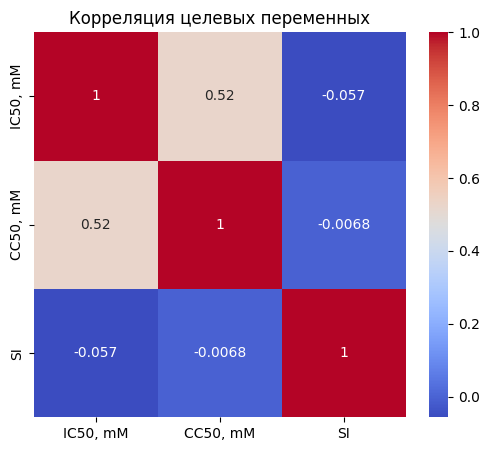

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[['IC50, mM','CC50, mM','SI']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Корреляция целевых переменных')
plt.show()

Сильные корреляционные связи между целевыми переменными отсутствуют

Проверка гипотезы, что SI = CC50 / IC50. Если это так, то сумма модулей разностей CC50 / IC50 и SI по наблюдениям будет стремиться к 0.

In [12]:
(df['CC50, mM'] / df['IC50, mM'] - df['SI']).abs().mean()

np.float64(9.032310017580543e-15)

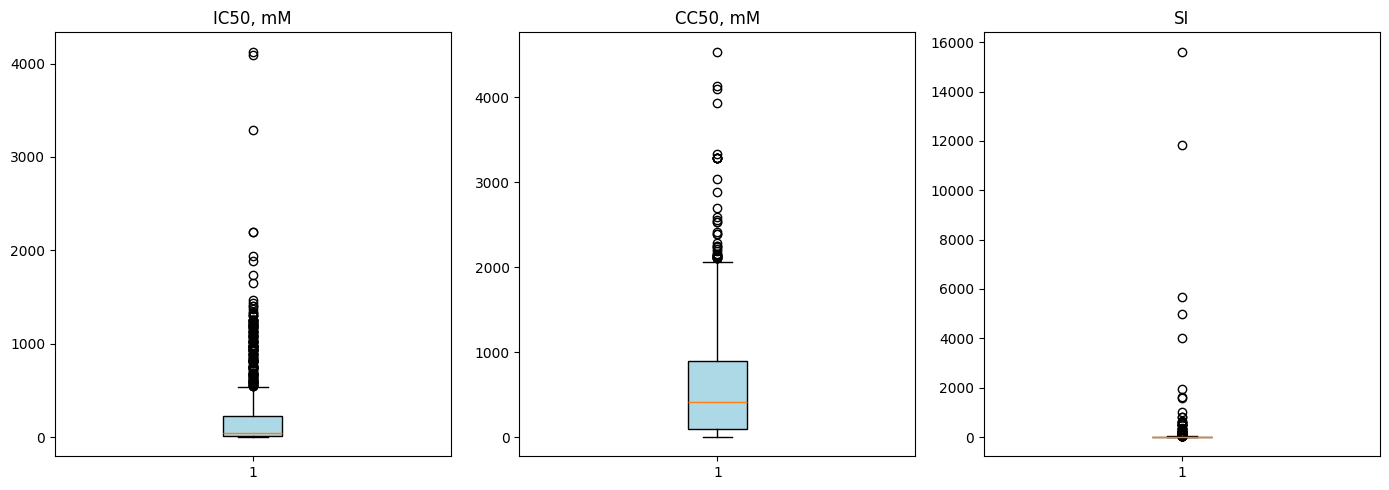

,target,outliers_1.5IQR,outliers_3IQR,p99
0,"IC50, mM",147,89,1440.49
1,"CC50, mM",39,11,3284.33
2,SI,125,87,807.73


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, col in enumerate(targets):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)
plt.tight_layout()
plt.show()
# потенциальные выбросы
outlier_info = []
for col in targets:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n15 = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    n30 = ((df[col] < q1 - 3*iqr) | (df[col] > q3 + 3*iqr)).sum()
    p99 = df[col].quantile(0.99)
    outlier_info.append([col, n15, n30, round(p99, 2)])
pd.DataFrame(outlier_info, columns=['target', 'outliers_1.5IQR', 'outliers_3IQR', 'p99'])

Медианы всех трех показателей расположены ближе к нижним квартилям. У SI огромный диапазон значений - большое число потенциальных выбросов.

Рассмотрим также, есть ли сильные положительные и отрицательные связи между признаками и целевыми переменными

In [15]:
targets = ['IC50, mM', 'CC50, mM','SI']
ic50_cor_pos = df.corr(numeric_only=True)['IC50, mM'].drop(targets).sort_values(ascending=False)

print("Положительные корреляции IC50 с признаками:")
ic50_cor_pos.head(10)

Положительные корреляции IC50 с признаками:


fr_Nhpyrrole        0.245511
fr_Ar_NH            0.245511
fr_nitro            0.215948
FpDensityMorgan1    0.208710
BCUT2D_CHGLO        0.203161
BalabanJ            0.196842
FpDensityMorgan2    0.187991
MaxPartialCharge    0.179227
fr_alkyl_halide     0.166763
BCUT2D_MWLOW        0.157783
Name: IC50, mM, dtype: float64

In [16]:
ic50_cor_neg = df.corr(numeric_only=True)['IC50, mM'].drop(targets).sort_values(ascending=True)

print("Отрицательные корреляции IC50 с признаками:")
ic50_cor_neg.head(10)

Отрицательные корреляции IC50 с признаками:


VSA_EState4   -0.274203
Chi2n         -0.257058
PEOE_VSA7     -0.255988
Chi2v         -0.249164
Chi4v         -0.243600
Chi4n         -0.243497
Chi3n         -0.239741
Chi3v         -0.237759
SlogP_VSA5    -0.236393
Chi1n         -0.229828
Name: IC50, mM, dtype: float64

In [17]:
cc50_cor_pos = df.corr(numeric_only=True)['CC50, mM'].drop(targets).sort_values(ascending=False)

print("Положительные корреляции CC50 с признаками:")
cc50_cor_pos.head(10)

Положительные корреляции CC50 с признаками:


FpDensityMorgan1    0.293989
FpDensityMorgan2    0.256608
HallKierAlpha       0.215193
BCUT2D_CHGLO        0.205016
BalabanJ            0.189650
fr_Ar_NH            0.160234
fr_Nhpyrrole        0.160234
BCUT2D_LOGPLOW      0.157918
MinPartialCharge    0.156863
FractionCSP3        0.145238
Name: CC50, mM, dtype: float64

In [18]:
cc50_cor_neg = df.corr(numeric_only=True)['CC50, mM'].drop(targets).sort_values(ascending=True)

print("Отрицательные корреляции CC50 с признаками:")
cc50_cor_neg.head(10)

Отрицательные корреляции CC50 с признаками:


MolMR            -0.310111
LabuteASA        -0.309191
MolWt            -0.306439
ExactMolWt       -0.306382
HeavyAtomCount   -0.305169
Chi0             -0.304792
Chi1             -0.304380
HeavyAtomMolWt   -0.303163
Kappa1           -0.302206
Chi1v            -0.301525
Name: CC50, mM, dtype: float64

In [19]:
SI_cor_pos = df.corr(numeric_only=True)['SI'].drop(targets).sort_values(ascending=False)

print("Положительные корреляции SI с признаками:")
SI_cor_pos.head(10)

Положительные корреляции SI с признаками:


BalabanJ            0.162955
fr_NH2              0.160470
fr_Al_COO           0.102414
fr_COO              0.101115
fr_COO2             0.101115
VSA_EState4         0.087837
FpDensityMorgan1    0.087341
NHOHCount           0.079143
EState_VSA2         0.071385
SMR_VSA5            0.065983
Name: SI, dtype: float64

In [20]:
SI_cor_neg = df.corr(numeric_only=True)['SI'].drop(targets).sort_values(ascending=True)

print("Отрицательные корреляции SI с признаками:")
SI_cor_neg.head(10)

Отрицательные корреляции SI с признаками:


RingCount                  -0.124444
NumAromaticRings           -0.088064
VSA_EState6                -0.082995
NumAromaticCarbocycles     -0.078311
fr_benzene                 -0.078311
SMR_VSA7                   -0.076521
AvgIpc                     -0.075626
NumAliphaticHeterocycles   -0.075313
MolLogP                    -0.074679
BCUT2D_LOGPHI              -0.074522
Name: SI, dtype: float64

Сильных зависимостей между таргетами и признаками нет.

In [21]:
corr_matrix = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI']).corr().abs()

top_corr_features = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

top_corr_features

fr_phenol               fr_phenol_noOrthoHbond    1.000000
NumAromaticCarbocycles  fr_benzene                1.000000
fr_Ar_NH                fr_Nhpyrrole              1.000000
MaxAbsEStateIndex       MaxEStateIndex            1.000000
fr_COO                  fr_COO2                   1.000000
MolWt                   ExactMolWt                0.999999
Chi1                    HeavyAtomCount            0.998742
MolWt                   HeavyAtomMolWt            0.996850
HeavyAtomMolWt          ExactMolWt                0.996821
Chi0                    HeavyAtomCount            0.995957
dtype: float64

Среди признаков есть сильные связи. Перед обучением моделей необходимо снизить размерность

### Предобработка данных

Как было показано выше, распределения целевых переменных асимметричны и имеют большой диапазон, поэтому создаем логарифмированные версии

In [22]:
df['log_IC50'] = np.log1p(df['IC50, mM'])
df['log_CC50'] = np.log1p(df['CC50, mM'])
df['log_SI'] = np.log1p(df['SI'])

C:\Users\admin\AppData\Local\Temp\ipykernel_26200\2889287145.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_IC50'] = np.log1p(df['IC50, mM'])
C:\Users\admin\AppData\Local\Temp\ipykernel_26200\2889287145.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['log_CC50'] = np.log1p(df['CC50, mM'])
C:\Users\admin\AppData\Local\Temp\ipykernel_26200\2889287145.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider j

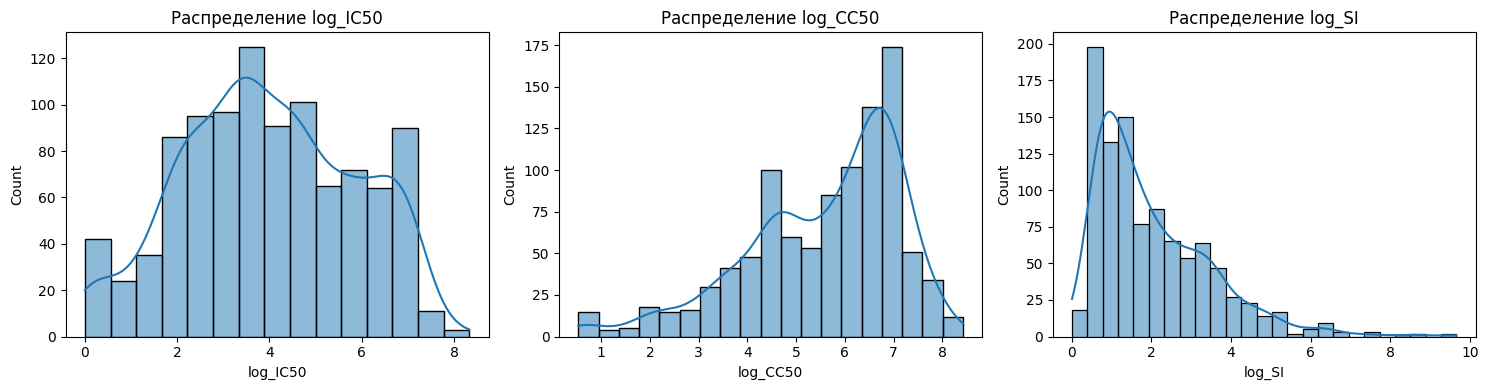

In [23]:
log_targets = ['log_IC50', 'log_CC50', 'log_SI']

plt.figure(figsize=(15,4))

for i, col in enumerate(log_targets, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')

plt.tight_layout()
plt.show()

In [24]:
df.to_csv("train_data_preprocessed.csv", index=False)

Выводы по EDA: датасет содержит 1001 химическое соединение, 3 целевых показателя(IC50,CC50 и SI) - параметры, характеризующие эффективность и 210 числовых признаков. В данных было небольшое количество пропусков, которые были заполнены медианами. Проверил, что SI фактически является CC50/IC50. По анализу распределений IC50,CC50 и SI: сильная правая ассиметрия и наличие выбросов, поэтому таргеты были прологарифмированы. Сильных корреляций между таргетами и признаками отсутствуют, однако, существуют сильные связи между некоторыми признаками, что необходимо будет учесть перед обучением моделей. 